# Icechunk Example Usage

Our icechunk repository is stored on arraylake. See [their documentation](https://docs.earthmover.io/setup/org-access#authenticating-as-a-user) for how to authenticate.

In [1]:
import arraylake as al
import xarray as xr

The first step is opening the icechunk from the arraylake repository

In [2]:
client = al.Client()
repo = client.get_repo("GFDL/noaa-gfdl-spear-large-ensembles-pds")

Then we can start a read-only session and load the data into an xarray DataTree

In [3]:
session = repo.readonly_session("main")
dt = xr.open_datatree(session.store, engine='zarr')

/work/a3r/conda/envs/aria/lib/python3.13/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


You can browse the datasets by looking at the DataTree object

In [4]:
dt

<xarray.DataTree>
Group: /
├── Group: /historical
│   ├── Group: /historical/6hr
│   │       Dimensions:        (member_id: 30, time: 131488, lat: 360, lon: 576,
│   │                           experiment_id: 1, bnds: 2)
│   │       Coordinates:
│   │         * member_id      (member_id) <U9 1kB 'r10i1p1f1' 'r11i1p1f1' ... 'r9i1p1f1'
│   │         * time           (time) object 1MB 1921-01-01 03:00:00 ... 2010-12-31 21:00:00
│   │         * lat            (lat) float64 3kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
│   │         * lon            (lon) float64 5kB 0.3125 0.9375 1.562 ... 358.4 359.1 359.7
│   │         * experiment_id  (experiment_id) <U10 40B 'historical'
│   │           lat_bnds       (lat, bnds) float64 6kB ...
│   │           lon_bnds       (lon, bnds) float64 9kB ...
│   │           time_bnds      (time, bnds) object 2MB ...
│   │       Dimensions without coordinates: bnds
│   │       Data variables:
│   │           pr             (member_id, time, lat, lon) float32 3TB ...
│   │       Attributes: (12/48)
│   │           Conventions:            CF-1.7 CMIP-6.2
│   │           activity_id:            SPEAR
│   │           branch_method:          Initial conditions for this ensemble member were ...
│   │           branch_time_in_child:   0.0
│   │           branch_time_in_parent:  0.0
│   │           contact:                gfdl.climate.model.info@noaa.gov
│   │           ...                     ...
│   │           variable_id:            pr
│   │           variant_label:          r10i1p1f1
│   │           cmor_version:           3.13.0
│   │           parent_experiment_id:   none
│   │           title:                  GFDL-SPEAR-MED output prepared for FLP
│   │           license:                CC0-1.0
│   ├── Group: /historical/Amon
│   │       Dimensions:        (member_id: 30, time: 1128, plev: 17, lat: 360, lon: 576,
│   │                           bnds: 2, experiment_id: 1)
│   │       Coordinates:
│   │         * member_id      (member_id) <U9 1kB 'r10i1p1f1' 'r11i1p1f1' ... 'r9i1p1f1'
│   │         * time           (time) object 9kB 1921-01-16 12:00:00 ... 2014-12-16 12:00:00
│   │         * plev           (plev) float64 136B 1e+05 9.25e+04 8.5e+04 ... 2e+03 1e+03
│   │         * lat            (lat) float64 3kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
│   │         * lon            (lon) float64 5kB 0.3125 0.9375 1.562 ... 358.4 359.1 359.7
│   │         * bnds           (bnds) float64 16B 1.0 2.0
│   │           lat_bnds       (lat, bnds) float64 6kB ...
│   │           lon_bnds       (lon, bnds) float64 9kB ...
│   │           time_bnds      (time, bnds) object 18kB ...
│   │         * experiment_id  (experiment_id) <U10 40B 'historical'
│   │       Data variables: (12/14)
│   │           hus            (member_id, time, plev, lat, lon) float32 477GB ...
│   │           pr             (member_id, time, lat, lon) float32 28GB ...
│   │           psl            (member_id, time, lat, lon) float32 28GB ...
│   │           rsut           (member_id, time, lat, lon) float32 28GB ...
│   │           tas            (member_id, time, lat, lon) float32 28GB ...
│   │           ua             (member_id, time, plev, lat, lon) float32 477GB ...
│   │           ...             ...
│   │           rsdt           (member_id, time, lat, lon) float32 28GB ...
│   │           rlut           (member_id, time, lat, lon) float32 28GB ...
│   │           vas            (member_id, time, lat, lon) float32 28GB ...
│   │           uas            (member_id, time, lat, lon) float32 28GB ...
│   │           zg             (member_id, time, plev, lat, lon) float32 477GB ...
│   │           va             (member_id, time, plev, lat, lon) float32 477GB ...
│   │       Attributes: (12/28)
│   │           history:                File was processed by fremetar (GFDL analog of CM...
│   │           table_id:               Amon
│   │           contact:                gfdl.climate.model.info@noaa.gov
│   │           experimen

and make plots of ensemble averages easily!

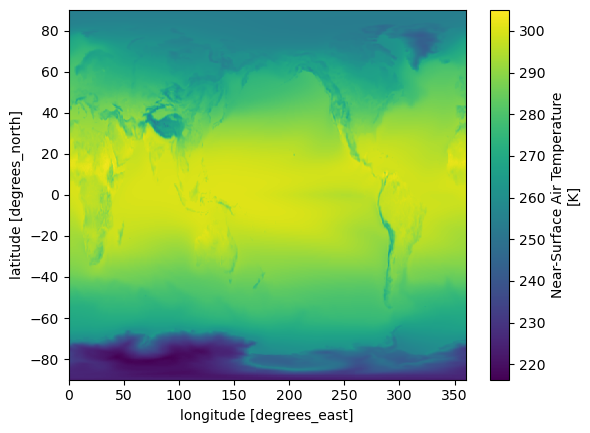

In [ ]:
dt['historical/Amon']['tas'].mean(dim=['time', 'member_id']).plot()